# Space Titanic

승객이 반이 다른 차원으로 사라졌다.
기존 승객 리스트를 보고 어떤 사람이 사라졌는지 알 수 있는 모델을 만들어보자.

our task is to predict the value of Transported for the passengers in this set.

## 1. 데이터 확인

In [1]:
import pandas as pd
dataset_df = pd.read_csv('train.csv')
dataset_df.head()

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True


In [2]:
dataset_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8693 entries, 0 to 8692
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   PassengerId   8693 non-null   object 
 1   HomePlanet    8492 non-null   object 
 2   CryoSleep     8476 non-null   object 
 3   Cabin         8494 non-null   object 
 4   Destination   8511 non-null   object 
 5   Age           8514 non-null   float64
 6   VIP           8490 non-null   object 
 7   RoomService   8512 non-null   float64
 8   FoodCourt     8510 non-null   float64
 9   ShoppingMall  8485 non-null   float64
 10  Spa           8510 non-null   float64
 11  VRDeck        8505 non-null   float64
 12  Name          8493 non-null   object 
 13  Transported   8693 non-null   bool   
dtypes: bool(1), float64(6), object(7)
memory usage: 891.5+ KB


In [3]:
dataset_df.describe()

,Age,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck
count,8514.000000,8512.000000,8510.000000,8485.000000,8510.000000,8505.000000
mean,28.827930,224.687617,458.077203,173.729169,311.138778,304.854791
std,14.489021,666.717663,1611.489240,604.696458,1136.705535,1145.717189
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,19.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,27.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,38.000000,47.000000,76.000000,27.000000,59.000000,46.000000
max,79.000000,14327.000000,29813.000000,23492.000000,22408.000000,24133.000000


전체 8693인데 count를 보면 8514다. 그럼 180명 정도가 정보가 없음

## 2. 데이터 시각화

돈을 많이 쓴 사람이 차원이동을 많이 했을까?

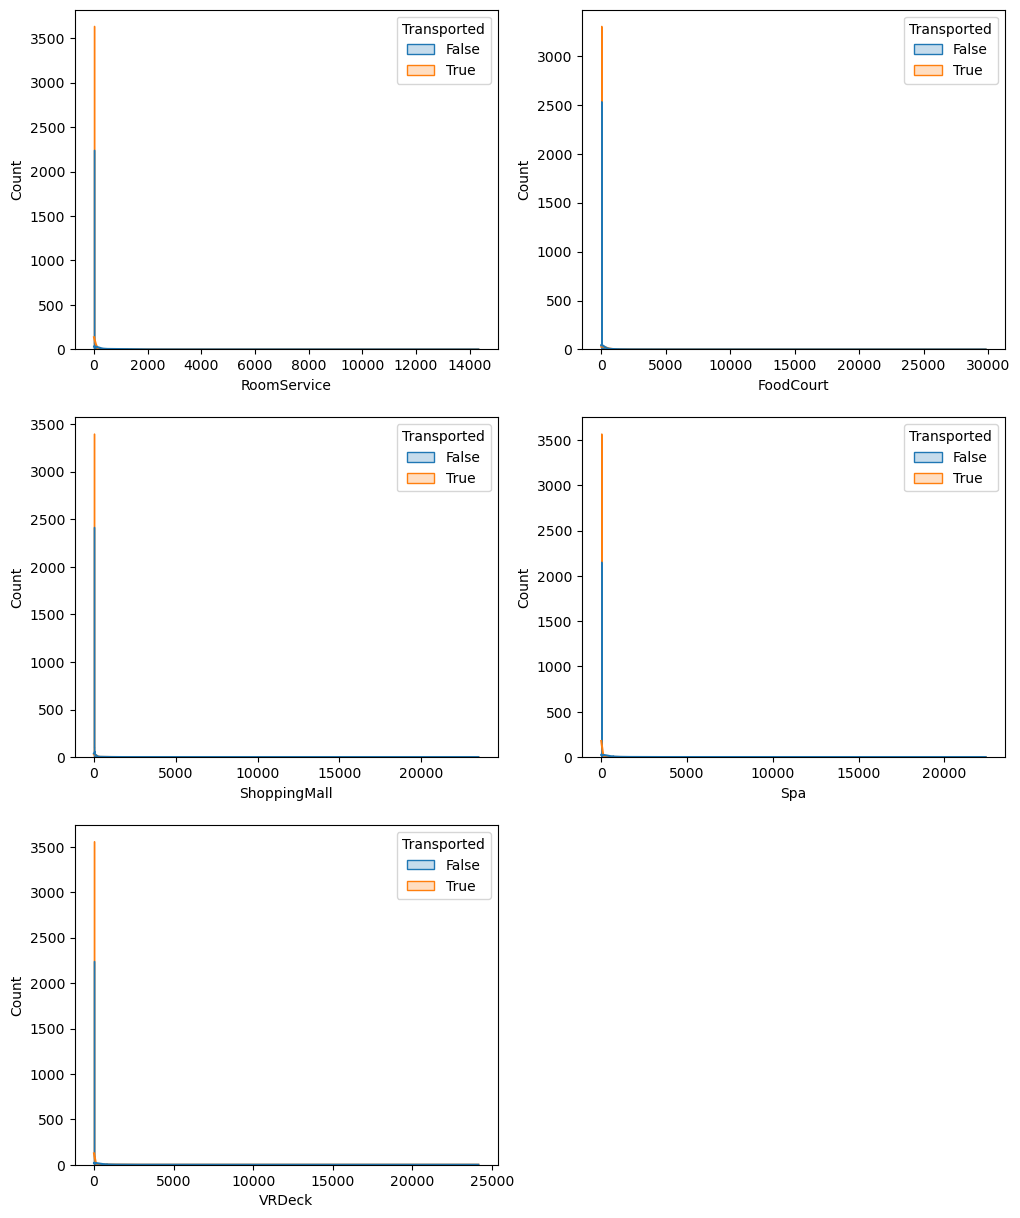

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

expense_cols = ['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']

plt.figure(figsize=(12, 15))

for i, col in enumerate(expense_cols):
    plt.subplot(3, 2, i+1)
    
    sns.histplot(data=dataset_df, x=col, hue='Transported', kde=True, element="step")

그래프가 잘 안보인다.

대부분은 돈을 거의 안쓰고 소수만 3000,6000씩 많이 썼다. 그래서 로그변환으로 압축한 후에 다시 시각화해보자 

In [5]:
import numpy as np

for col in expense_cols:
   # 빈칸은 돈을 안쓴거니까 우선 0으로 채우기 
    dataset_df[col] = dataset_df[col].fillna(0)
    dataset_df[col] = np.log1p(dataset_df[col])

# 로그변환한 값 다시 확인하기
dataset_df[expense_cols].describe()

,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck
count,8693.000000,8693.000000,8693.000000,8693.000000,8693.000000
mean,1.735295,1.906543,1.599415,1.838851,1.757950
std,2.719285,2.932951,2.567446,2.769368,2.746810
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000
75%,3.737670,4.127134,3.135494,3.988984,3.713572
max,9.569971,10.302733,10.064458,10.017218,10.091377


다시 시각화 해보자

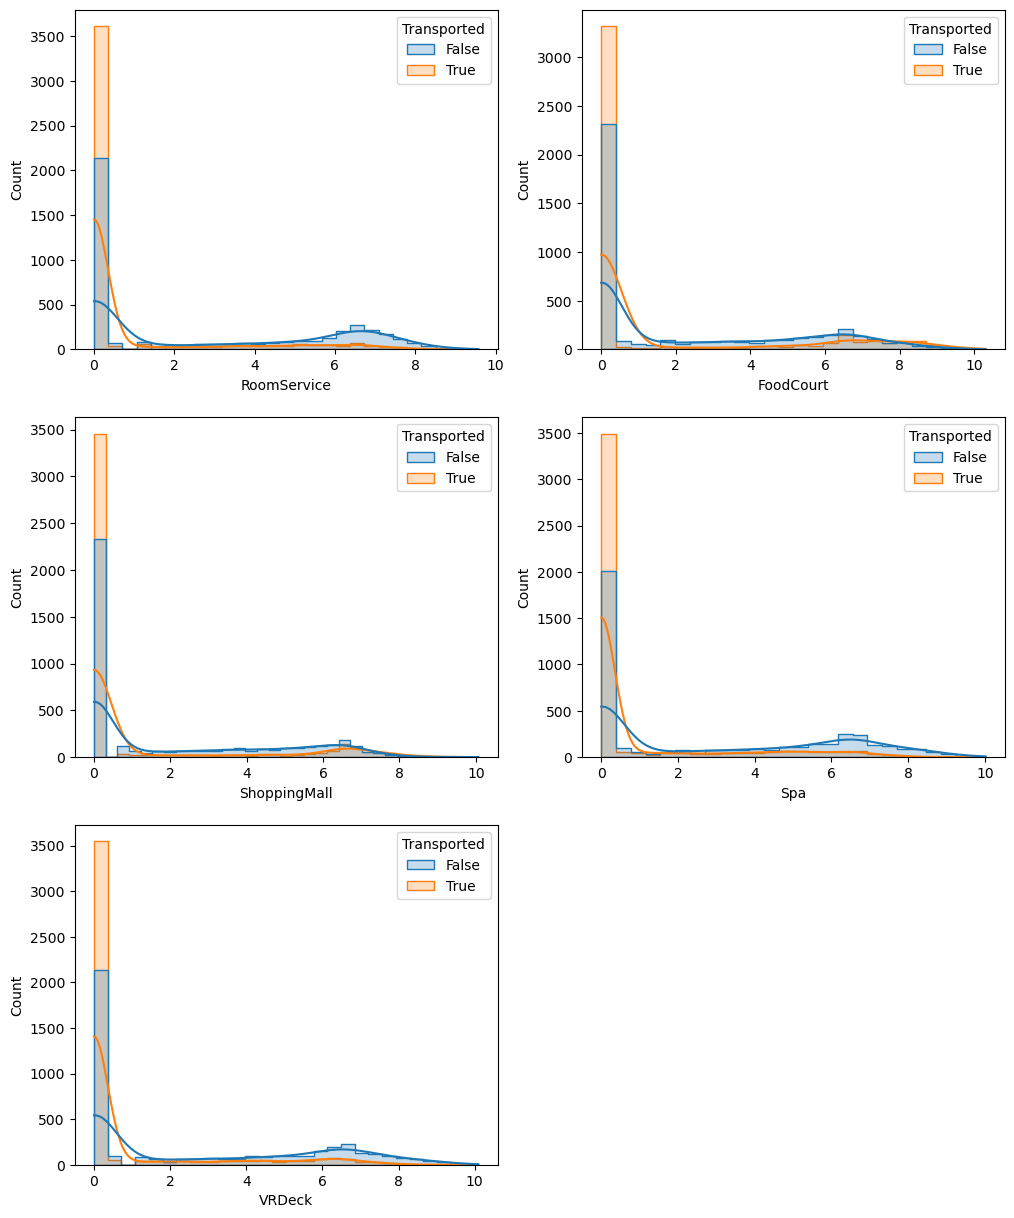

In [6]:
plt.figure(figsize=(12, 15))

for i, col in enumerate(expense_cols):
    plt.subplot(3, 2, i+1)
    
    # 로그 변환된 데이터를 히스토그램으로 그리기
    sns.histplot(data=dataset_df, x=col, hue='Transported', kde=True, element="step")

그래프를 보니 돈을 안 쓴 사람들이 주로 차원이동을 했다는 걸 알 수 있다.

## 3. 결측치 구하기
그럼 이제 결측치는 어떻게 처리할까. 우선 얼마나 빈칸이 있는지 보자

In [7]:
missing_values = dataset_df.isnull().sum()

print(missing_values)

PassengerId       0
HomePlanet      201
CryoSleep       217
Cabin           199
Destination     182
Age             179
VIP             203
RoomService       0
FoodCourt         0
ShoppingMall      0
Spa               0
VRDeck            0
Name            200
Transported       0
dtype: int64


(1) 우선 cryosleep 한 사람이 더 많이 사라졌는지? 확인해보자

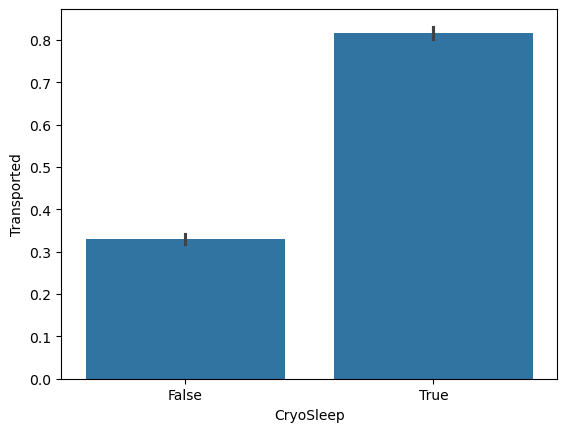

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.barplot(data=dataset_df, x='CryoSleep', y='Transported')
plt.show()

실제로 잠잔 사람들이 더 사라진 사람이 많다.

(2) 어린아이들이면 덜 사라졌을까? 나이대별 차원이동 한 사람을 살펴보자

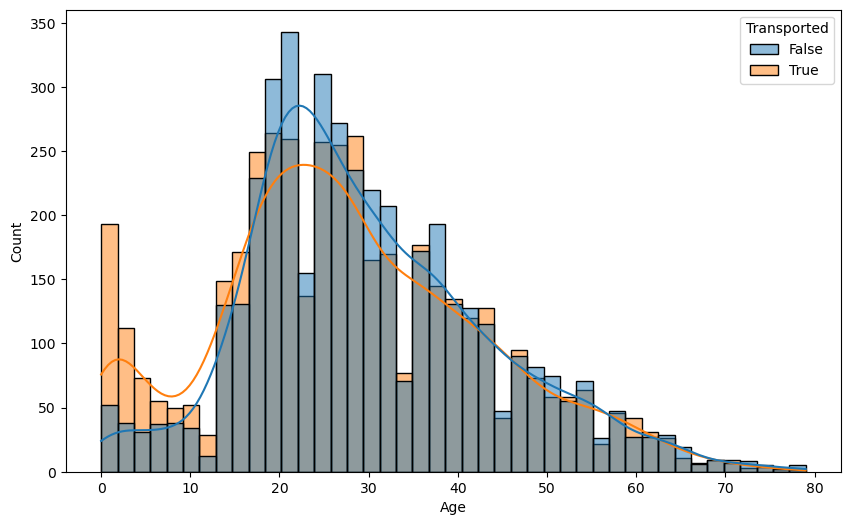

In [9]:

plt.figure(figsize=(10, 6))
sns.histplot(data=dataset_df, x='Age', hue='Transported', kde=True)
plt.show()

그래프를 보면 0~ 10살은 차원이동한 사람이 많고, 20대는 남아있는 사람이 더 많다.\
그래서 0~10살 어린이들이 차원이동할 확률 높음.

### 결측치 채우기

나이를 먼저 채워보자.
평균값으로 하면 이상치 영향을 받으니 중간값으로 해보자

In [10]:
print("age 빈칸 개수:", dataset_df['Age'].isnull().sum())

age 빈칸 개수: 179


In [11]:
age_median = dataset_df['Age'].median()

print("나이 중간값은:", age_median)

나이 중간값은: 27.0


In [12]:

dataset_df['Age'] = dataset_df['Age'].fillna(age_median)

print("age 빈칸 개수:", dataset_df['Age'].isnull().sum())

age 빈칸 개수: 0


나이 결측치를 중간값 27로 채움

남은 빈칸도 채워보자. 글자는 최빈값으로 채워주자. 숫자가 아니라서 가장 많이 나온 값이 대부분으로 생각하고 채워준다.

In [14]:
char_cols = ['HomePlanet', 'CryoSleep', 'Destination', 'VIP']

for col in char_cols:
    dataset_df[col] = dataset_df[col].fillna(dataset_df[col].mode()[0])

cabin 데이터 deck/cabin_num/side로 쪼개기 / 기준으로 쪼개기

In [15]:

dataset_df[['Deck', 'Num', 'Side']] = dataset_df['Cabin'].str.split('/', expand=True)

print(dataset_df[['Deck', 'Num', 'Side']].head())

  Deck Num Side
0    B   0    P
1    F   0    S
2    A   0    S
3    A   0    S
4    F   1    S


cabin 쪼개고 deck 구역별로 차원이동 한 사람이 차이가 나는지 확인해보자

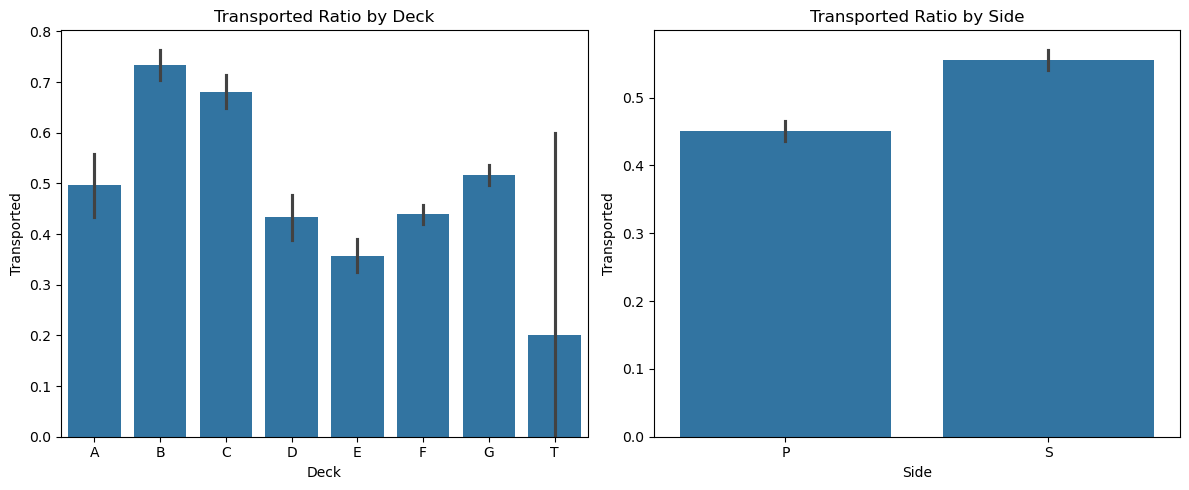

In [16]:
# 구역별로 차원이동 한 사람 차이가 나는지?
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.barplot(data=dataset_df, x='Deck', y='Transported', order=['A', 'B', 'C', 'D', 'E', 'F', 'G', 'T'])
plt.title('Transported Ratio by Deck')

# Side별로 다른지 확인
plt.subplot(1, 2, 2)
sns.barplot(data=dataset_df, x='Side', y='Transported')
plt.title('Transported Ratio by Side')

plt.tight_layout()
plt.show()

cabin 쪼개서 시각화 해보니 B,C 구역이 차원이동 확률이 높고, S쪽 방향인 사람들이 차원이동한 경우가 높다.

이 ABCDEFGT를 모델이 읽을 수 있도록 글자를 숫자로 바꿔줘야한다. 

라벨 인코딩

In [17]:
from sklearn.preprocessing import LabelEncoder

# 숫자로 바꿀 리스트
encoding_cols = ['HomePlanet', 'CryoSleep', 'Destination', 'VIP', 'Deck', 'Side']

for col in encoding_cols:
    le = LabelEncoder()
    dataset_df[col] = le.fit_transform(dataset_df[col].astype(str))

dataset_df[encoding_cols].head()

,HomePlanet,CryoSleep,Destination,VIP,Deck,Side
0,1,0,2,0,1,0
1,0,0,2,0,5,1
2,1,0,2,1,0,1
3,1,0,2,0,0,1
4,0,0,2,0,5,1


맞춰야하는 tranported 를 분리하고, 큰 영향을 주지 않는 것을 삭제해보자

In [18]:
X = dataset_df.drop(columns=['Transported', 'Name'])

# 맞춰야 하는 transported는 빼둔다.
y = dataset_df['Transported']

print(X.columns.tolist())

['PassengerId', 'HomePlanet', 'CryoSleep', 'Cabin', 'Destination', 'Age', 'VIP', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck', 'Deck', 'Num', 'Side']


In [19]:
X

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Deck,Num,Side
0,0001_01,1,0,B/0/P,2,39.0,0,0.000000,0.000000,0.000000,0.000000,0.000000,1,0,0
1,0002_01,0,0,F/0/S,2,24.0,0,4.700480,2.302585,3.258097,6.309918,3.806662,5,0,1
2,0003_01,1,0,A/0/S,2,58.0,1,3.784190,8.182280,0.000000,8.812248,3.912023,0,0,1
3,0003_02,1,0,A/0/S,2,33.0,0,0.000000,7.157735,5.918894,8.110728,5.267858,0,0,1
4,0004_01,0,0,F/1/S,2,16.0,0,5.717028,4.262680,5.023881,6.338594,1.098612,5,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8688,9276_01,1,0,A/98/P,0,41.0,1,0.000000,8.827615,0.000000,7.404888,4.317488,0,98,0
8689,9278_01,0,1,G/1499/S,1,18.0,0,0.000000,0.000000,0.000000,0.000000,0.000000,6,1499,1
8690,9279_01,0,0,G/1500/S,2,26.0,0,0.000000,0.000000,7.535297,0.693147,0.000000,6,1500,1
8691,9280_01,1,0,E/608/S,0,32.0,0,0.000000,6.956545,0.000000,5.869297,8.082093,4,608,1


이미 deck num side로 잘라줬으니까 기존꺼는 지우자

In [20]:
X = dataset_df.drop(columns=['Transported', 'Name', 'Cabin'])

In [21]:
X

,PassengerId,HomePlanet,CryoSleep,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Deck,Num,Side
0,0001_01,1,0,2,39.0,0,0.000000,0.000000,0.000000,0.000000,0.000000,1,0,0
1,0002_01,0,0,2,24.0,0,4.700480,2.302585,3.258097,6.309918,3.806662,5,0,1
2,0003_01,1,0,2,58.0,1,3.784190,8.182280,0.000000,8.812248,3.912023,0,0,1
3,0003_02,1,0,2,33.0,0,0.000000,7.157735,5.918894,8.110728,5.267858,0,0,1
4,0004_01,0,0,2,16.0,0,5.717028,4.262680,5.023881,6.338594,1.098612,5,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8688,9276_01,1,0,0,41.0,1,0.000000,8.827615,0.000000,7.404888,4.317488,0,98,0
8689,9278_01,0,1,1,18.0,0,0.000000,0.000000,0.000000,0.000000,0.000000,6,1499,1
8690,9279_01,0,0,2,26.0,0,0.000000,0.000000,7.535297,0.693147,0.000000,6,1500,1
8691,9280_01,1,0,0,32.0,0,0.000000,6.956545,0.000000,5.869297,8.082093,4,608,1


y 데이터 분포도 확인해보자

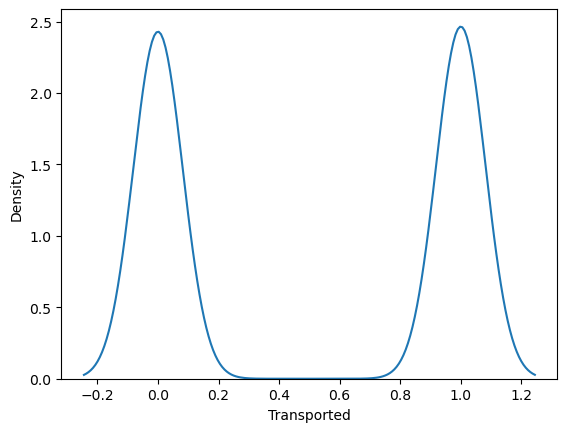

In [22]:
sns.kdeplot(y)
plt.show()

In [23]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8693 entries, 0 to 8692
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   PassengerId   8693 non-null   object 
 1   HomePlanet    8693 non-null   int64  
 2   CryoSleep     8693 non-null   int64  
 3   Destination   8693 non-null   int64  
 4   Age           8693 non-null   float64
 5   VIP           8693 non-null   int64  
 6   RoomService   8693 non-null   float64
 7   FoodCourt     8693 non-null   float64
 8   ShoppingMall  8693 non-null   float64
 9   Spa           8693 non-null   float64
 10  VRDeck        8693 non-null   float64
 11  Deck          8693 non-null   int64  
 12  Num           8494 non-null   object 
 13  Side          8693 non-null   int64  
dtypes: float64(6), int64(6), object(2)
memory usage: 950.9+ KB


모델 학습에 활용하려면 모두 실수 또는 정수 자료형이어야 하는데. 다시 해보자

In [24]:
# 삭제하기
X = X.drop(columns=['PassengerId'])
# 숫자로 바꿔주기
X['Num'] = X['Num'].fillna(0).astype(int)

In [25]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8693 entries, 0 to 8692
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   HomePlanet    8693 non-null   int64  
 1   CryoSleep     8693 non-null   int64  
 2   Destination   8693 non-null   int64  
 3   Age           8693 non-null   float64
 4   VIP           8693 non-null   int64  
 5   RoomService   8693 non-null   float64
 6   FoodCourt     8693 non-null   float64
 7   ShoppingMall  8693 non-null   float64
 8   Spa           8693 non-null   float64
 9   VRDeck        8693 non-null   float64
 10  Deck          8693 non-null   int64  
 11  Num           8693 non-null   int64  
 12  Side          8693 non-null   int64  
dtypes: float64(6), int64(7)
memory usage: 883.0 KB


오케이. 모델 학습에 필요한 자료형으로 완료

test 데이터에도 똑같이 전처리 해주자

In [44]:
test_df = pd.read_csv('test.csv')

# 결측치 채우기(숫자는 중간값, 글자는 최빈값으로)
test_df['Age'] = test_df['Age'].fillna(dataset_df['Age'].median())
test_df['HomePlanet'] = test_df['HomePlanet'].fillna(dataset_df['HomePlanet'].mode()[0])

# 로그 변환 
for col in ['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']:
    test_df[col] = np.log1p(test_df[col].fillna(0))

# Cabin 쪼개기
test_df[['Deck', 'Num', 'Side']] = test_df['Cabin'].fillna('U/0/U').str.split('/', expand=True)

from sklearn.preprocessing import LabelEncoder

# 라벨인코딩 하기
encoding_cols = ['HomePlanet', 'CryoSleep', 'Destination', 'VIP', 'Deck', 'Side']
for col in encoding_cols:
    le = LabelEncoder()
    # 글자를 숫자로 바꾸기
    test_df[col] = le.fit_transform(test_df[col].astype(str))

test_df['Num'] = test_df['Num'].fillna(0).astype(int)

# 결과낼때 필요한 승객 번호는 따로 보관하기
test_passenger_id = test_df['PassengerId']

# train 데이터에서 뺀거 똑같이 빼주기
X_test = test_df.drop(columns=['PassengerId', 'Cabin', 'Name'], errors='ignore')

### 4. 모델학습

랜덤 포레스트 사용해서 학습시켜보자

(의사결정 하는 나무를 모아서 마지막에 Voting으로 결정하는것) 

In [45]:
from sklearn.ensemble import RandomForestClassifier

# 100개의 트리를 사용하는거고, 실행할때 마다 결과 달라지지 않게 고정하는 random_state 번호
model = RandomForestClassifier(n_estimators=100, random_state=42)

model.fit(X,y)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


전처리 했던 test 데이터로 차원이동 했는지 여부 맞춰보기

In [47]:
X_test = test_df[X.columns]

predictions = model.predict(X_test)

In [49]:
import pandas as pd

#데이터프레임 만들기
submission = pd.DataFrame({
    "PassengerId": test_df['PassengerId'], # 원본 test데이터에서 가져오기
    "Transported": predictions.astype(bool) # 0과 1로 나온 결과를 다시 False true로 바꾸기
})

# 파일로 저장하기
submission.to_csv('submission.csv', index=False)

submission.head()

,PassengerId,Transported
0,0013_01,True
1,0018_01,False
2,0019_01,True
3,0021_01,True
4,0023_01,True


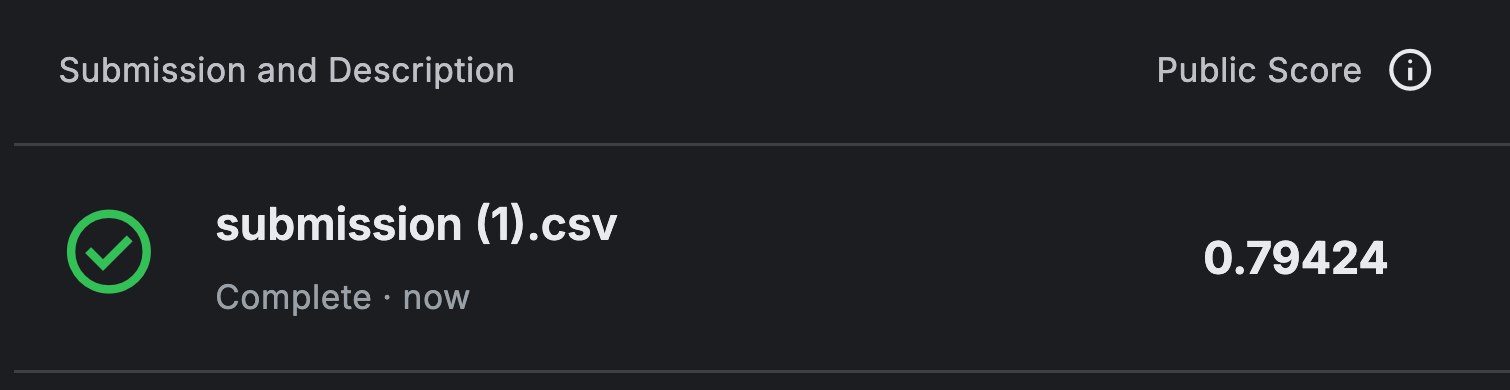

# 회고

유지할점: 그래프로 그려보면서 직관적으로 보이는 부분과 해결해야하는 부분을 알 수 있었습니다.

어려웠던 점: 분명 지난 시간에 배워서 눈에 익긴했는데 직접적으로 이해를 잘 못한 부분이 많았습니다. 그래서 캐글의 다른 사람이 한 내용을 보고 ai한테 접근방식 등을 물어보면서 이게 무슨 의미인지, 왜 쓰는지를 물어보면서 진행했습니다. 
모델학습을 하는 부분에서 train 데이터와 test 데이터 전처리를 하면서 데이터 타입이 오브젝트가 남아있어서 오류가 떠서 
앞으로 꼼꼼히 확인해야겠다는 생각도 했습니다.

시도할 점: 라벨 인코딩보다 원핫인코딩을 쓰는게 더 낫다고 들어서 다음에는 제대로 활용해봐야겠습니다. 지금은 좀 여기저기 정리되어 있지 않는 상황인데, 다음에는 좀 더 제대로 익혀서 깔끔하게 써야하지 않나 싶습니다. (우선 제대로 익히는 것 부터 필요)